<a href="https://colab.research.google.com/github/Ogombo-collins/Analysing-Healthcare-Facilities-in-Kenya/blob/main/Kenya's_Healthcare_Analysis_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of Health Facilities in Kenya


**Scope/Data Source:**

A comprehensive list of health facilities in Kenya, complete with services offered as well as granular geo-data (Provincial, County, District, Location, Sub-Location and Division information) The data is updated monthly, on the 3rd week.


Sources of data:

1. Health facilities data: Health facilities in Kenya <a href="https://open.africa/dataset/health-facilities-in-kenya" target="_blank" rel="noopener">Health facilities in Kenya </a>


2. Population census data per county in kenya (2019):   <a href="https://www.knbs.or.ke/wp-content/uploads/2023/09/2019-Kenya-population-and-Housing-Census-Volume-1-Population-By-County-And-Sub-County.pdf" target="_blank" rel="noopener">Counties population</a>

In [105]:
import pandas as pd
import numpy as np


# ----------------------------------------
# 1. DATA LOADING
# ----------------------------------------
df = pd.read_csv('/content/drive/MyDrive/Analytics Projects_August - Dec 2025/Substack Crazy Data Insights/Health facilities in Kenya/ehealth-kenya-facilities.csv')
df.head()






,Facility Code,Facility Name,Province,County,District,Division,Type,Owner,Location,Sub Location,...,IPD,OPD,OUTREACH,PMTCT,RAD/XRAY,RHTC/RHDC,TB DIAG,TB LABS,TB TREAT,YOUTH
0,19224,CDF Kiriari Dispensary,Eastern,Embu,Manyatta,Manyatta,Dispensary,Ministry of Health,Ruguru,Ruguru,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19310,St Jude's Huruma Community Health Services,Nairobi,Nairobi,Mathare,Huruma,Medical Clinic,Private Practice - Unspecified,Huruma,Huruma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,14180,10 Engineer VCT,Rift Valley,Laikipia,Laikipia East,Central,Dispensary,Armed Forces,Nanyuki,Majengo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17486,12 Engineers,Central,Kiambu,Thika West,NaN,Dispensary,Ministry of Health,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18393,3Kl Maternity & Nursing Home,Rift Valley,Kajiado,Kajiado North,Ongata Rongai,Nursing Home,Private Practice - Clinical Officer,Gataka,Gataka,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [106]:
#inspect dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10505 entries, 0 to 10504
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Facility Code            10505 non-null  int64  
 1   Facility Name            10505 non-null  object 
 2   Province                 10505 non-null  object 
 3   County                   10505 non-null  object 
 4   District                 10505 non-null  object 
 5   Division                 10238 non-null  object 
 6   Type                     10505 non-null  object 
 7   Owner                    10505 non-null  object 
 8   Location                 10010 non-null  object 
 9   Sub Location             9613 non-null   object 
 10  Description of Location  5304 non-null   object 
 11  Constituency             10505 non-null  object 
 12  Nearest Town             9903 non-null   object 
 13  Beds                     10418 non-null  float64
 14  Cots                  

In [107]:
# print distinct number of counties, constituencies and types
print("Distinct Counties:",df['County'].nunique())


print("Distinct Constituencies:",df['Constituency'].nunique())

print("Distinct Types:",df['Type'].nunique())

Distinct Counties: 47
Distinct Constituencies: 223
Distinct Types: 26


In [108]:
#distribution of Type
df['Type'].value_counts(normalize=True)*100

,proportion
Type,
Dispensary,45.882913
Medical Clinic,31.984769
Health Centre,10.718705
Other Hospital,2.436935
Nursing Home,1.980010
VCT Centre (Stand-Alone),1.722989
Sub-District Hospital,1.361257
District Hospital,1.342218
Laboratory (Stand-alone),0.561637


# New augmented Analysis

##  Data Wrangling & Cleansing

In [109]:

# ----------------------------------------
# STEP 2: CLEAN FACILITY DATA
# ----------------------------------------
print("\n[Step 2/7] Cleaning and preparing facility data...")

# --- 2a. Clean Capacity Columns ---
df['Beds'] = df['Beds'].fillna(0).astype(int)
df['Cots'] = df['Cots'].fillna(0).astype(int)
df['Total_Capacity'] = df['Beds'] + df['Cots']


# --- 2b. Handle Operational Columns ---
# Standardize 'Open 24 Hours' and 'Open Weekends'
# Map 'Y' to 1, and all else ('N', 'N/A', NaN) to 0
df['Open_24_Hours'] = df['Open 24 Hours'].apply(lambda x: 1 if x == 'Y' else 0)
df['Open_Weekends'] = df['Open Weekends'].apply(lambda x: 1 if x == 'Y' else 0)

# Inspect 'Operational Status'
# print("\nUnique 'Operational Status' values:")
# print(df['Operational Status'].value_counts())
df['Is_Operational'] = df['Operational Status'].apply(lambda x: 1 if x == 'Operational' else 0)

# --- 2c. Handle Service Columns (Based on Data Inspection) ---
# Define columns that are unusable (all NaN)
empty_service_cols = [
'ANC', 'BEOC', 'BLOOD', 'CAES SEC', 'CEOC', 'EPI', 'GROWM', 'HCT',
'OPD', 'OUTREACH', 'PMTCT', 'RAD/XRAY', 'RHTC/RHDC', 'TB DIAG',
'TB LABS', 'TB TREAT', 'YOUTH'
]

# Define columns that have *some* data
usable_service_cols = ['ART', 'C-IMCI', 'FP', 'HBC', 'IPD']

# Map 'Y' to 1 and all other values (NaN, 'N', etc.) to 0 for usable columns
for col in usable_service_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'Y' else 0)

# --- 2d. Drop Unnecessary/Empty Columns ---
# We drop the original object-type operational columns and all empty service columns
cols_to_drop = ['Open 24 Hours', 'Open Weekends'] + empty_service_cols
df_cleaned = df.drop(columns=cols_to_drop)

print("Data cleaning complete.")




[Step 2/7] Cleaning and preparing facility data...
Data cleaning complete.


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10505 entries, 0 to 10504
Data columns (total 54 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Facility Code            10505 non-null  int64  
 1   Facility Name            10505 non-null  object 
 2   Province                 10505 non-null  object 
 3   County                   10505 non-null  object 
 4   District                 10505 non-null  object 
 5   Division                 10238 non-null  object 
 6   Type                     10505 non-null  object 
 7   Owner                    10505 non-null  object 
 8   Location                 10010 non-null  object 
 9   Sub Location             9613 non-null   object 
 10  Description of Location  5304 non-null   object 
 11  Constituency             10505 non-null  object 
 12  Nearest Town             9903 non-null   object 
 13  Beds                     10505 non-null  int64  
 14  Cots                  

In [111]:
# is_Operational value counts
df_cleaned['Is_Operational'].value_counts()

,count
Is_Operational,
1,9551
0,954


In [112]:
# filter dataset to only include: 'Is_Opeartional' == 1
df_cleaned = df_cleaned[df_cleaned['Is_Operational'] == 1]

## Preliminary Analysis

In [113]:
# Q1: What is the distribution of facilities by Owner?
print("\nFacilities by Owner:")
print(df_cleaned['Owner'].value_counts(normalize=False).head(5))

# Q2: What is the distribution of facilities by Type?
print("\nFacilities by Type:")
print(df_cleaned['Type'].value_counts(normalize=False).head(5))

# Q3: What is the total patient capacity (Beds + Cots) by Province?
print("\nTotal Capacity (Beds + Cots) by Province:")
print(df_cleaned.groupby('Province')['Total_Capacity'].sum().sort_values(ascending=False))

# Q4: What percentage of facilities offer the 5 key services?
print("\n% of Facilities Offering Key Services:")
for col in usable_service_cols:
  percent_offering = (df_cleaned[col].sum() / len(df_cleaned)) * 100
  print(f"  - {col}: {percent_offering:.2f}%")

# Q5: How many facilities are NOT operational?
non_operational_count = len(df_cleaned[df_cleaned['Is_Operational'] == 0])
print(f"\nNon-Operational Facilities: {non_operational_count} ({(non_operational_count/len(df_cleaned)*100):.2f}%)")

# Q6: What percentage of 'Hospitals' are open 24 hours?
hospitals_df = df_cleaned[df_cleaned['Type'].str.contains('Hospital', case=False, na=False)]
hospitals_24hr_percent = (hospitals_df['Open_24_Hours'].sum() / len(hospitals_df)) * 100
print(f"\n% of Hospitals Open 24 Hours: {hospitals_24hr_percent:.2f}%")


Facilities by Owner:
Owner
Ministry of Health                         4138
Private Enterprise (Institution)           1252
Private Practice - Nurse / Midwife          947
Private Practice - Clinical Officer         585
Private Practice - General Practitioner     421
Name: count, dtype: int64

Facilities by Type:
Type
Dispensary        4159
Medical Clinic    3136
Health Centre     1102
Other Hospital     250
Nursing Home       197
Name: count, dtype: int64

Total Capacity (Beds + Cots) by Province:
Province
Rift Valley      15677
Nyanza           10576
Eastern          10326
Nairobi           8352
Central           7319
Western           5352
Coast             4043
North Eastern     1842
Name: Total_Capacity, dtype: int64

% of Facilities Offering Key Services:
  - ART: 9.57%
  - C-IMCI: 12.12%
  - FP: 43.70%
  - HBC: 28.79%
  - IPD: 40.36%

Non-Operational Facilities: 0 (0.00%)

% of Hospitals Open 24 Hours: 72.66%


## Visualizations for Preliminary Analysis

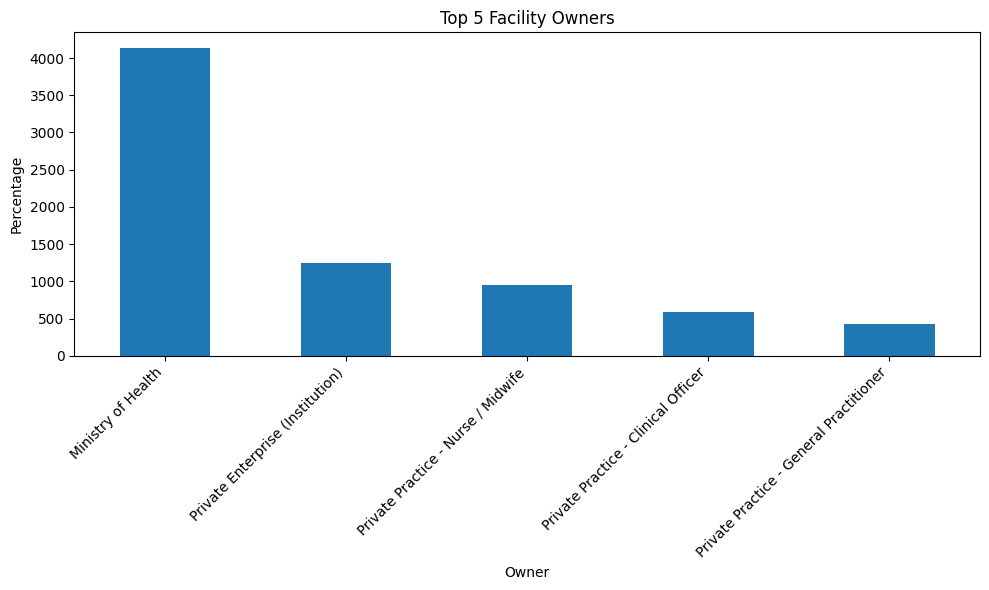

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Q1: What is the distribution of facilities by Owner?
plt.figure(figsize=(10, 6))
df_cleaned['Owner'].value_counts(normalize=False).head(5).plot(kind='bar')
plt.title('Top 5 Facility Owners')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

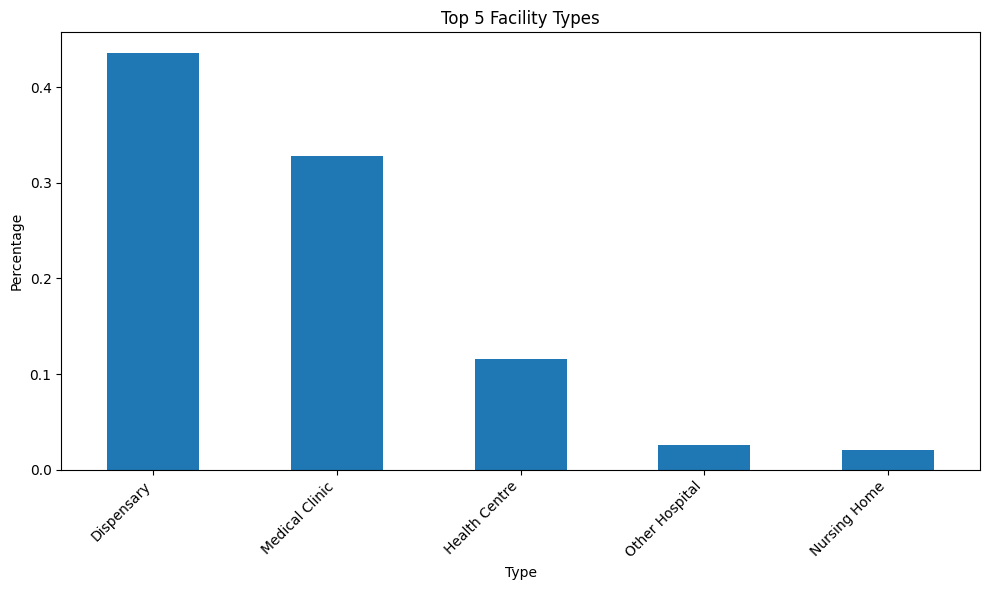

In [115]:
# Q2: What is the distribution of facilities by Type?
plt.figure(figsize=(10, 6))
df_cleaned['Type'].value_counts(normalize=True).head(5).plot(kind='bar')
plt.title('Top 5 Facility Types')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

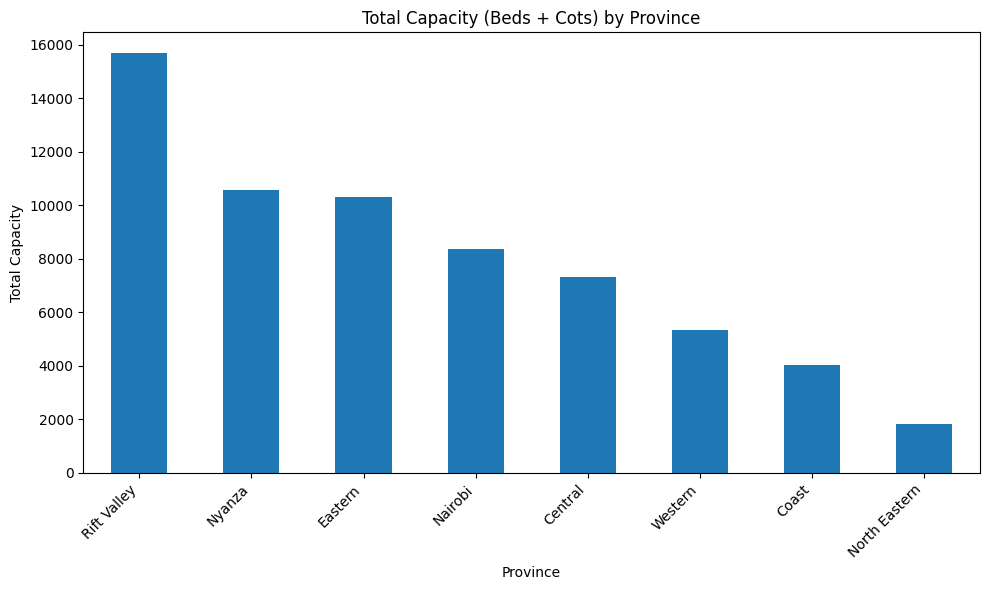

In [116]:
# Q3: What is the total patient capacity (Beds + Cots) by Province?
plt.figure(figsize=(10, 6))
df_cleaned.groupby('Province')['Total_Capacity'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Capacity (Beds + Cots) by Province')
plt.ylabel('Total Capacity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

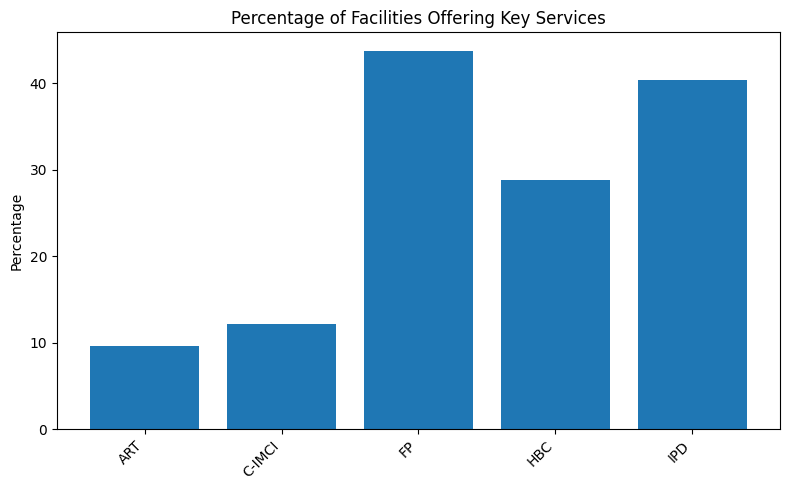

In [117]:
# Q4: What percentage of facilities offer the 5 key services?
service_percentages = {col: (df_cleaned[col].sum() / len(df_cleaned[col])) * 100 for col in usable_service_cols}
plt.figure(figsize=(8, 5))
plt.bar(service_percentages.keys(), service_percentages.values())
plt.title('Percentage of Facilities Offering Key Services')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [118]:
# # Q5: How many facilities are NOT operational?
# operational_counts = df_cleaned['Operational_status'].value_counts()
# plt.figure(figsize=(6, 6))
# plt.pie(operational_counts, labels=['Operational', 'Non-Operational'], autopct='%1.1f%%', startangle=90)
# plt.title('Operational Status of Facilities')
# plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
# plt.show()

## Deeper Analysis

In [119]:
# ----------------------------------------
# STEP 3: CREATE 2019 POPULATION DATAFRAME
# ----------------------------------------
print("\n[Step 3/7] Creating 2019 population dataset (KNBS Census)...")

# Data sourced from KNBS 2019 Census
pop_data = {
  'County': ['Mombasa', 'Kwale', 'Kilifi', 'Tana River', 'Lamu', 'Taita Taveta',
              'Garissa', 'Wajir', 'Mandera', 'Marsabit', 'Isiolo', 'Meru',
              'Tharaka Nithi', 'Embu', 'Kitui', 'Machakos', 'Makueni', 'Nyandarua',
              'Nyeri', 'Kirinyaga', "Murang'a", 'Kiambu', 'Turkana', 'West Pokot',
              'Samburu', 'Trans Nzoia', 'Uasin Gishu', 'Elgeyo Marakwet', 'Nandi',
              'Baringo', 'Laikipia', 'Nakuru', 'Narok', 'Kajiado', 'Kericho',
              'Bomet', 'Kakamega', 'Vihiga', 'Bungoma', 'Busia', 'Siaya',
              'Kisumu', 'Homa Bay', 'Migori', 'Kisii', 'Nyamira', 'Nairobi'],
  'Population_2019': [1208333, 866820, 1453787, 315943, 143920, 340671, 841353,
                      781263, 867457, 459785, 268002, 1545714, 393177, 608599,
                      1136187, 1421932, 987653, 638289, 759164, 610411, 1056640,
                      2417735, 926976, 621241, 310327, 990341, 1163186, 454480,
                      885711, 666763, 518560, 2162202, 1157873, 1117840, 901777,
                      875689, 1867579, 590013, 1670570, 893681, 993183, 1155574,
                      1131950, 1116436, 1266860, 605576, 4397073]
}
df_population = pd.DataFrame(pop_data)
print(f"-> Population DataFrame created. Shape: {df_population.shape}")

    # ----------------------------------------




[Step 3/7] Creating 2019 population dataset (KNBS Census)...
-> Population DataFrame created. Shape: (47, 2)


In [120]:
# STEP 4: AGGREGATE FACILITY DATA BY COUNTY
# ----------------------------------------
print("\n[Step 4/7] Standardizing and aggregating facility data by county...")

# --- 4a. Standardize County Names for merging ---
df_facilities_clean = df_cleaned.copy()
df_facilities_clean['County'] = df_facilities_clean['County'].str.title().str.strip()

# Standardize known name mismatches
df_facilities_clean['County'] = df_facilities_clean['County'].replace({
'Elgeyo/Marakwet': 'Elgeyo Marakwet',
'Taita/Taveta': 'Taita Taveta',
'Tharaka': 'Tharaka Nithi',
'Nairobi City': 'Nairobi',
'Muranga': "Murang'a",
'Trans-Nzoia': 'Trans Nzoia'
})

# --- 4b. Aggregate by County ---
df_facility_agg = df_facilities_clean.groupby('County').agg(
Facility_Count=('Facility Code', 'count'),
Total_Capacity=('Total_Capacity', 'sum'),
ART_Facility_Count=('ART', 'sum'),
IPD_Facility_Count=('IPD', 'sum'),
FP_Facility_Count=('FP', 'sum'),
Open_24h_Count=('Open_24_Hours', 'sum')
).reset_index()

print("-> Facility data aggregated by County.")

df_facility_agg.head()



[Step 4/7] Standardizing and aggregating facility data by county...
-> Facility data aggregated by County.


,County,Facility_Count,Total_Capacity,ART_Facility_Count,IPD_Facility_Count,FP_Facility_Count,Open_24h_Count
0,Baringo,203,766,4,98,108,21
1,Bomet,129,1935,5,47,45,19
2,Bungoma,166,1250,21,73,85,40
3,Busia,107,1146,21,51,43,27
4,Elgeyo Marakwet,123,840,5,38,36,9


In [121]:
# ----------------------------------------
# STEP 5: MERGE FACILITY & POPULATION DATA
# ----------------------------------------
print("\n[Step 5/7] Merging aggregated facility data with population data...")

# Perform an inner merge
df_merged = pd.merge(df_facility_agg, df_population, on='County', how='inner')
print(f"-> Successfully merged data. {df_merged.shape[0]} counties matched.")
print("-> First 5 rows of merged data:")
print(df_merged.head().to_markdown(index=False))

# ----------------------------------------
# STEP 6: CALCULATE DENSITY METRICS
# ----------------------------------------
print("\n[Step 6/7] Calculating new population density metrics...")

df_merged['Facilities_Per_100k_People'] = (df_merged['Facility_Count'] / df_merged['Population_2019']) * 100000
df_merged['Beds_Per_1000_People'] = (df_merged['Total_Capacity'] / df_merged['Population_2019']) * 1000
df_merged['ART_Clinics_Per_100k_People'] = (df_merged['ART_Facility_Count'] / df_merged['Population_2019']) * 100000

print("-> Density metrics calculated.")



[Step 5/7] Merging aggregated facility data with population data...
-> Successfully merged data. 46 counties matched.
-> First 5 rows of merged data:
| County          |   Facility_Count |   Total_Capacity |   ART_Facility_Count |   IPD_Facility_Count |   FP_Facility_Count |   Open_24h_Count |   Population_2019 |
|:----------------|-----------------:|-----------------:|---------------------:|---------------------:|--------------------:|-----------------:|------------------:|
| Baringo         |              203 |              766 |                    4 |                   98 |                 108 |               21 |            666763 |
| Bomet           |              129 |             1935 |                    5 |                   47 |                  45 |               19 |            875689 |
| Bungoma         |              166 |             1250 |                   21 |                   73 |                  85 |               40 |           1670570 |
| Busia           |     

In [122]:
# ----------------------------------------
# STEP 7: SHOW FINAL ANALYSIS & EXPORT
# ----------------------------------------
print("\n[Step 7/7] Final Analysis & Export...")

# --- Top 5 Counties with FEWEST Facilities per 100k People ---
print("\n--- ANALYSIS: Top 5 Counties with FEWEST Facilities per 100k People (Potentially Underserved) ---")
print(df_merged.sort_values('Facilities_Per_100k_People', ascending=True)[
  ['County', 'Population_2019', 'Facility_Count', 'Facilities_Per_100k_People']
].head().to_markdown(index=False))

# --- Top 5 Counties with FEWEST Beds per 1,000 People ---
print("\n--- ANALYSIS: Top 5 Counties with FEWEST Beds per 1,000 People (Lowest Capacity) ---")
print(df_merged.sort_values('Beds_Per_1000_People', ascending=True)[
  ['County', 'Population_2019', 'Total_Capacity', 'Beds_Per_1000_People']
].head().to_markdown(index=False))

# --- Top 5 Counties with MOST Facilities per 100k People ---
print("\n--- ANALYSIS: Top 5 Counties with MOST Facilities per 100k People (Potentially Best-Served) ---")
print(df_merged.sort_values('Facilities_Per_100k_People', ascending=False)[
  ['County', 'Population_2019', 'Facility_Count', 'Facilities_Per_100k_People']
].head().to_markdown(index=False))




[Step 7/7] Final Analysis & Export...

--- ANALYSIS: Top 5 Counties with FEWEST Facilities per 100k People (Potentially Underserved) ---
| County   |   Population_2019 |   Facility_Count |   Facilities_Per_100k_People |
|:---------|------------------:|-----------------:|-----------------------------:|
| Mandera  |            867457 |               76 |                      8.76124 |
| Bungoma  |           1670570 |              166 |                      9.93673 |
| Busia    |            893681 |              107 |                     11.973   |
| Kisii    |           1266860 |              162 |                     12.7875  |
| Kwale    |            866820 |              116 |                     13.3822  |

--- ANALYSIS: Top 5 Counties with FEWEST Beds per 1,000 People (Lowest Capacity) ---
| County      |   Population_2019 |   Total_Capacity |   Beds_Per_1000_People |
|:------------|------------------:|-----------------:|-----------------------:|
| Mandera     |            867457 |

## Visualizations for Deeper Analysis

<Figure size 1000x600 with 0 Axes>

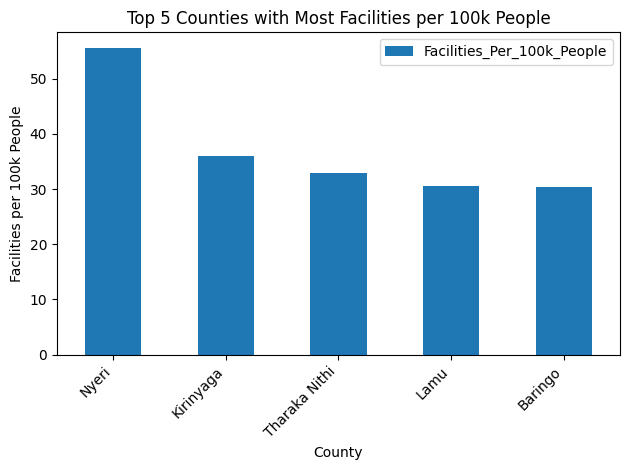

In [123]:
# Visualization for "Top 5 Counties with MOST Facilities per 100k People"
plt.figure(figsize=(10, 6))
df_merged.sort_values('Facilities_Per_100k_People', ascending=False).head().plot(x='County', y='Facilities_Per_100k_People', kind='bar')
plt.title('Top 5 Counties with Most Facilities per 100k People')
plt.ylabel('Facilities per 100k People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

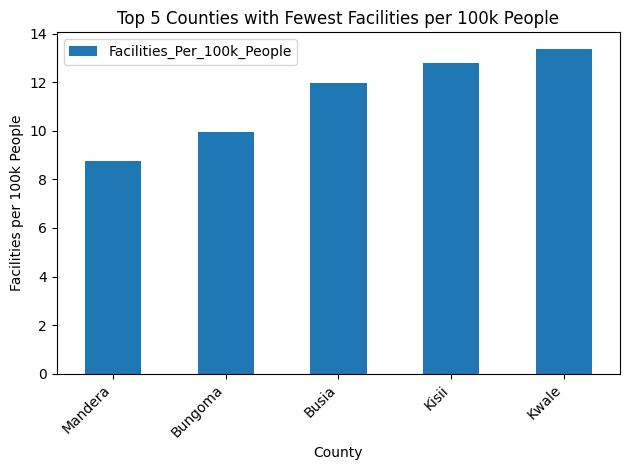

In [124]:
# Visualization for "Top 5 Counties with FEWEST Facilities per 100k People"
plt.figure(figsize=(10, 6))
df_merged.sort_values('Facilities_Per_100k_People', ascending=True).head().plot(x='County', y='Facilities_Per_100k_People', kind='bar')
plt.title('Top 5 Counties with Fewest Facilities per 100k People')
plt.ylabel('Facilities per 100k People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

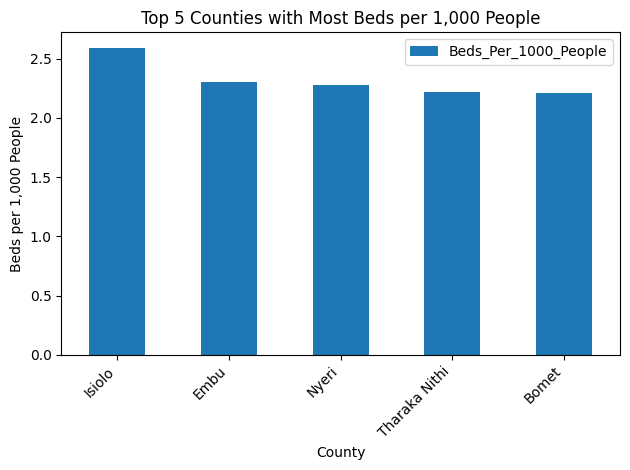

In [125]:
# Visualization for "Beds per 1,000 People"
plt.figure(figsize=(10, 6))
df_merged.sort_values('Beds_Per_1000_People', ascending=False).head().plot(x='County', y='Beds_Per_1000_People', kind='bar')
plt.title('Top 5 Counties with Most Beds per 1,000 People')
plt.ylabel('Beds per 1,000 People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

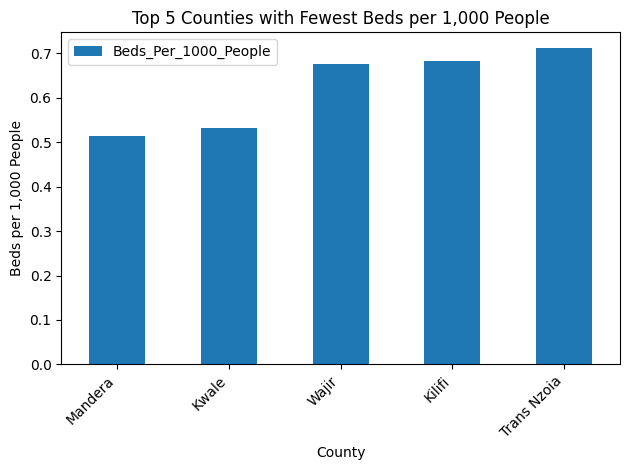

In [126]:
# Visualization for "Top 5 Counties with FEWEST Beds per 1,000 People"
plt.figure(figsize=(10, 6))
df_merged.sort_values('Beds_Per_1000_People', ascending=True).head().plot(x='County', y='Beds_Per_1000_People', kind='bar')
plt.title('Top 5 Counties with Fewest Beds per 1,000 People')
plt.ylabel('Beds per 1,000 People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

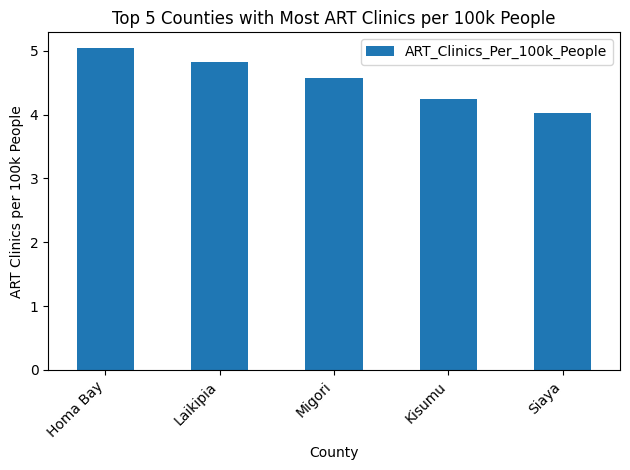

In [127]:
# Visualization for "ART Clinics per 100k People"
plt.figure(figsize=(10, 6))
df_merged.sort_values('ART_Clinics_Per_100k_People', ascending=False).head().plot(x='County', y='ART_Clinics_Per_100k_People', kind='bar')
plt.title('Top 5 Counties with Most ART Clinics per 100k People')
plt.ylabel('ART Clinics per 100k People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

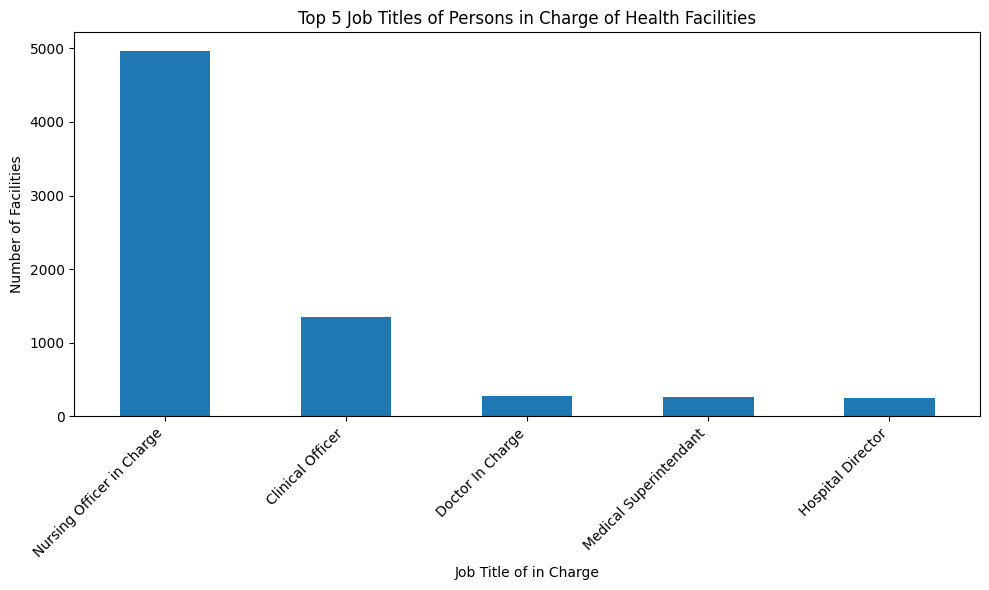

In [128]:
#visualizing people in charge of health facilities
df_cleaned['Job Title of in Charge'].value_counts()



plt.figure(figsize=(10, 6))
df_cleaned['Job Title of in Charge'].value_counts().head().plot(kind='bar')
plt.title('Top 5 Job Titles of Persons in Charge of Health Facilities')
plt.ylabel('Number of Facilities')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [129]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   County                       46 non-null     object 
 1   Facility_Count               46 non-null     int64  
 2   Total_Capacity               46 non-null     int64  
 3   ART_Facility_Count           46 non-null     int64  
 4   IPD_Facility_Count           46 non-null     int64  
 5   FP_Facility_Count            46 non-null     int64  
 6   Open_24h_Count               46 non-null     int64  
 7   Population_2019              46 non-null     int64  
 8   Facilities_Per_100k_People   46 non-null     float64
 9   Beds_Per_1000_People         46 non-null     float64
 10  ART_Clinics_Per_100k_People  46 non-null     float64
dtypes: float64(3), int64(7), object(1)
memory usage: 4.1+ KB


In [130]:
df_merged.columns.to_list()

['County',
 'Facility_Count',
 'Total_Capacity',
 'ART_Facility_Count',
 'IPD_Facility_Count',
 'FP_Facility_Count',
 'Open_24h_Count',
 'Population_2019',
 'Facilities_Per_100k_People',
 'Beds_Per_1000_People',
 'ART_Clinics_Per_100k_People']

In [131]:
df_merged.head()

,County,Facility_Count,Total_Capacity,ART_Facility_Count,IPD_Facility_Count,FP_Facility_Count,Open_24h_Count,Population_2019,Facilities_Per_100k_People,Beds_Per_1000_People,ART_Clinics_Per_100k_People
0,Baringo,203,766,4,98,108,21,666763,30.445601,1.148834,0.599913
1,Bomet,129,1935,5,47,45,19,875689,14.731257,2.209689,0.570979
2,Bungoma,166,1250,21,73,85,40,1670570,9.936728,0.748248,1.257056
3,Busia,107,1146,21,51,43,27,893681,11.972952,1.282337,2.349832
4,Elgeyo Marakwet,123,840,5,38,36,9,454480,27.063897,1.848266,1.100158


In [132]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9551 entries, 0 to 10504
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Facility Code            9551 non-null   int64  
 1   Facility Name            9551 non-null   object 
 2   Province                 9551 non-null   object 
 3   County                   9551 non-null   object 
 4   District                 9551 non-null   object 
 5   Division                 9334 non-null   object 
 6   Type                     9551 non-null   object 
 7   Owner                    9551 non-null   object 
 8   Location                 9141 non-null   object 
 9   Sub Location             8782 non-null   object 
 10  Description of Location  4950 non-null   object 
 11  Constituency             9551 non-null   object 
 12  Nearest Town             9058 non-null   object 
 13  Beds                     9551 non-null   int64  
 14  Cots                     955

### Other Questions (Bonus)

In [133]:
#1: Total number of facilities
df_cleaned['Facility Code'].nunique()

9551

In [134]:
#percentage opertional on weekends vs non-operational on weekends
df_cleaned.groupby('Open_Weekends')['Is_Operational'].value_counts(normalize=False)

,,count
Open_Weekends,Is_Operational,
0,1,6323
1,1,3228


In [147]:
#2: counties with facilities Open_Weekends: Top 10 counties
df_cleaned[(df_cleaned['Open_Weekends'] == 1)]['County'].value_counts().head(10)

,count
County,
Nairobi,509
Kiambu,204
Nakuru,174
Kajiado,156
Mombasa,142
Meru,107
Kilifi,104
Machakos,102
Kitui,93


In [136]:
# 3: Number of facilities opened 24hours:Top 10 counties
df_cleaned[(df_cleaned['Open_24_Hours'] == 1)]['County'].value_counts().head(10)

,count
County,
Nairobi,197
Kiambu,87
Mombasa,76
Nakuru,69
Kajiado,65
Kitui,58
Wajir,49
Kilifi,48
Makueni,48


In [137]:
# 4: Number of facilities Not opened 24hours:Top 10 counties
df_cleaned[(df_cleaned['Open_24_Hours'] == 0)]['County'].value_counts().head(10)

,count
County,
Nairobi,720
Nyeri,412
Meru,405
Kiambu,393
Nakuru,331
Machakos,272
Kitui,268
Murang'a,239
Mombasa,237


In [138]:
#5 : Number of facilities opened 24hours:Top 10 facilities by name
df_cleaned[(df_cleaned['Open_24_Hours'] == 1)]['Facility Name'].value_counts().head(10)


,count
Facility Name,
Malkamari Health Centre,2
Paradise Medical Centre,2
Nayanaeangikalalio Dispensary,2
Mwingi Nursing Home,1
Mwingi District Hospital,1
Mwera Medical Clinic,1
Mwea Mission (Our Lady of Lourdes) Hospital,1
Mwea Medical Centre,1
Mwea Annex Domic Medical Centre,1


In [139]:
#top 10 constitenciews with highest capacity
df_cleaned.groupby('Constituency')['Total_Capacity'].sum().sort_values(ascending=False).head(10)

,Total_Capacity
Constituency,
KIBRA,2225
BOMET,1481
KAMUKUNJI,1289
KISUMU TOWN EAST,1284
NAKURU TOWN,1273
KITUTU CHACHE,1187
ELDORET EAST,1075
JUJA,1037
MVITA,975


In [140]:
#sumary stats
df_merged.describe()

,Facility_Count,Total_Capacity,ART_Facility_Count,IPD_Facility_Count,FP_Facility_Count,Open_24h_Count,Population_2019,Facilities_Per_100k_People,Beds_Per_1000_People,ART_Clinics_Per_100k_People
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,4.600000e+01,46.000000,46.000000,46.000000
mean,202.195652,1361.913043,19.543478,81.282609,88.021739,33.891304,1.011036e+06,21.139105,1.351095,1.897320
std,148.887373,1270.770332,19.455598,49.633171,51.695041,31.197029,7.008708e+05,8.039518,0.513040,1.203411
min,44.000000,179.000000,1.000000,18.000000,12.000000,5.000000,1.439200e+05,8.761241,0.512994,0.293538
25%,119.250000,697.500000,7.000000,48.250000,50.250000,17.250000,6.090520e+05,15.972534,0.979633,0.899623
50%,164.000000,968.500000,14.500000,65.000000,85.000000,24.500000,8.896960e+05,19.814632,1.296796,1.725581
75%,224.750000,1724.250000,24.750000,102.250000,111.750000,41.500000,1.157298e+06,24.989291,1.557048,2.475361
max,917.000000,8352.000000,109.000000,288.000000,272.000000,197.000000,4.397073e+06,55.587462,2.593264,5.035558


In [141]:
# summary stats of df_cleaned
df_cleaned.describe()

,Facility Code,Beds,Cots,Official Alternate No,ART,C-IMCI,FP,HBC,IPD,Total_Capacity,Open_24_Hours,Open_Weekends,Is_Operational
count,9551.000000,9551.000000,9551.000000,9.080000e+02,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.0
mean,15579.166370,5.857711,0.789446,6.717907e+08,0.095697,0.121244,0.437022,0.287928,0.403623,6.647157,0.164381,0.337975,1.0
std,3195.777089,31.131317,11.832246,5.676178e+08,0.294190,0.326428,0.496044,0.452821,0.490649,37.176915,0.370640,0.473045,0.0
min,10001.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,12872.500000,0.000000,0.000000,7.137213e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,15466.000000,0.000000,0.000000,7.227721e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,18376.500000,2.000000,0.000000,7.279151e+08,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,0.000000,1.000000,1.0
max,21281.000000,1455.000000,1000.000000,7.382217e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1882.000000,1.000000,1.000000,1.0


In [142]:
df_cleaned['Total_Capacity'].sum()

np.int64(63487)

In [143]:
#county with minimum facility_count
low_facility_count = df_merged[df_merged['Facility_Count'] == df_merged['Facility_Count'].min()]

print(f"county with lowest number of health facilities: {low_facility_count['County'].values[0]}")

county with lowest number of health facilities: Lamu


In [144]:
#county with

In [145]:
#save df_merged as csv file called "Augmented health facilities per county in kenya.csv"
df_merged.to_csv('/content/drive/MyDrive/Analytics Projects_August - Dec 2025/Substack Crazy Data Insights/Health facilities in Kenya/Augmented health facilities per county in kenya.csv', index=False)

In [146]:
# save df_cleaned as csv file called "Kenyan health facilities.csv"

df_cleaned.to_csv('/content/drive/MyDrive/Analytics Projects_August - Dec 2025/Substack Crazy Data Insights/Health facilities in Kenya/Kenyan health facilities.csv')